# LAB 3A : Implement Simple Linear regression

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## import dataset

In [62]:
dataset = pd.read_csv('50_Startups_1000.csv')
dataset['R&D Spend'] = dataset['R&D Spend'].astype(float)
dataset['Administration'] = dataset['Administration'].astype(float)
dataset['Marketing Spend'] = dataset['Marketing Spend'].astype(float)
dataset['Profit'] = dataset['Profit'].astype(float)



## EDA Steps

In [63]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [64]:
dataset.shape

(1000, 5)

In [65]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [66]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        1000 non-null   float64
 1   Administration   1000 non-null   float64
 2   Marketing Spend  1000 non-null   float64
 3   State            1000 non-null   object 
 4   Profit           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [67]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45463.653075,27750.088166,121121.807234,39921.048333
min,0.000000,51283.140000,0.000000,14681.400000
25%,38558.510000,103057.490000,127716.820000,89949.140000
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101913.080000,145077.580000,299737.290000,141585.520000
max,165349.200000,182645.560000,471784.100000,192261.830000


## Preprocessing Steps

In [68]:
# Step 1 : Seprate i/p Independent Var and
# o/p Dependent Var
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [69]:
print(X.head())

   R&D Spend  Administration  Marketing Spend       State
0  165349.20       136897.80        471784.10    New York
1  162597.70       151377.59        443898.53  California
2  153441.51       101145.55        407934.54     Florida
3  144372.41       118671.85        383199.62    New York
4  142107.34        91391.77        366168.42     Florida


In [70]:
print(y.head())

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64


In [71]:
# Step 4 : Split data into training and testin
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split (X,y,
                                        test_size = 0.3,
                                        random_state = 0)

In [72]:
print(X_train.shape)
print(X_test.shape)

(700, 4)
(300, 4)


In [84]:
# Perform One-Hot Encoding on the 'State' column
from sklearn.preprocessing import OneHotEncoder
import pandas as pd # Ensure pandas is imported

encoder = OneHotEncoder(sparse_output=False)
state_encoded = encoder.fit_transform(dataset[['State']])
state_encoded_df = pd.DataFrame(state_encoded, columns=encoder.get_feature_names_out(['State']))

# Concatenate the encoded State columns with the rest of the dataset
dataset_encoded = pd.concat([dataset.drop('State', axis=1), state_encoded_df], axis=1)

# Separate the independent and dependent variables from the encoded dataset
X = dataset_encoded.drop('Profit', axis=1)
y = dataset_encoded['Profit']

# Split the encoded data into training and testing sets
from sklearn.model_selection import train_test_split # Ensure train_test_split is imported

X_train,X_test,y_train,y_test = train_test_split (X,y,
                                        test_size = 0.3,
                                        random_state = 0)

## Create the Regression model on training data

In [85]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train,y_train)

LinearRegression()

In [92]:
print("Intercept B0 = ",regressor.intercept_)
print("Coefficient B1= ",regressor.coef_)

Intercept B0 =  48833.54348701288
Coefficient B1=  [ 8.14871265e-01 -2.58354436e-02  2.75707735e-02  3.64972904e+01
  2.39887350e+02 -2.76384640e+02]


From Above values our model regression line equation

**y = 48833.543487012882 + 8.14871265e-01 * X**

By using this equation lets find profit of 5 years

In [93]:
ynew = 48833.54348701288 + 8.14871265e-01 * 5

print("Profit of 5 yrs = ",ynew)

Profit of 5 yrs =  48837.61784333788


In [95]:
ypred = regressor.predict(X_test)

In [96]:
print(ypred)
print(y_test)

[ 58881.05898106 154972.89501559  47662.05258008 173701.25720378
 114560.07132586 116725.6695551  113749.68351359  96862.56112096
 158282.61430726 158282.61430726  55344.87371857 151532.993953
  88439.07358715  82971.24954198 101435.62465924 163445.46618586
 158282.61430726 101761.77314021 149839.51807189 113749.68351359
  96862.56112096  96862.56112096 135580.36797255 135418.92742847
  97548.96781507  68445.77852128  46217.16148645 173701.25720378
 135580.36797255 189693.95284283 109774.33381961 135580.36797255
 149839.51807189  74002.53851941 151532.993953    74693.37365019
 160419.32973627 116587.38108286 129018.56335856 129733.20718427
  99115.86615794  55344.87371857  89521.70348089  47662.05258008
 189693.95284283  97548.96781507 115011.98393005  74148.61420538
 116587.38108286  88888.70751041  96862.56112096  46217.16148645
 129159.19161584  98472.2587487  129159.19161584  98472.2587487
 114560.07132586 116299.71835964  88888.70751041 115011.98393005
 115011.98393005  58881.0589

#### Accuracy of model

In [97]:
# 1. Training Accuracy

print("Training accuracy =",
      regressor.score(X_train,y_train))

Training accuracy = 0.9507317409280277


In [99]:
# 2. Testing Accuracy

print("Testing accuracy =",
      regressor.score(X_test,y_test))

Testing accuracy = 0.9496273844001412


### Visualizing the Model

#### 1. Visualize the training data

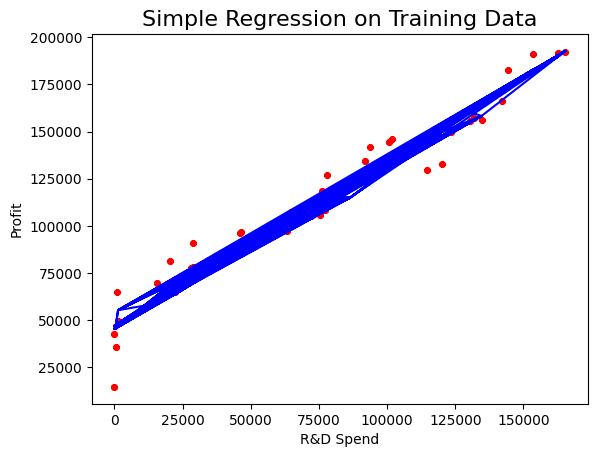

In [104]:
plt.scatter(X_train['R&D Spend'], y_train, color='red', s=12)
plt.plot(X_train['R&D Spend'], regressor.predict(X_train), color='blue')
plt.title("Simple Regression on Training Data", size=16)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.show()


#### 2. Visualize the testing data

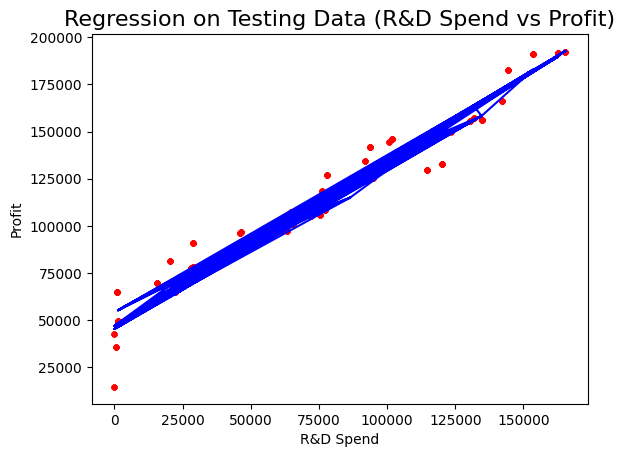

In [109]:
plt.scatter(X_test['R&D Spend'], y_test, color='red', s=12)
plt.plot(X_test['R&D Spend'], regressor.predict(X_test), color='blue')
plt.title("Regression on Testing Data (R&D Spend vs Profit)", size=16)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.show()


#### Find R^2 Score of model

In [110]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.9496273844001412

In [113]:
from sklearn.metrics import median_absolute_error
median_absolute_error(y_train, regressor.predict(X_train))

np.float64(5212.935015586641)

median_absolute_error(y_test, regressor.predict(X_test))